# Machine Learning Group Project - Transit Reliability and Neighbourhood Equity in Toronto

Training and Predictions


The Data from TTC is joined with the Neighborhood Profiles from the Census, so now we can read it in here

In [1]:
#required imports
import numpy as np
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(123)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


In [2]:
# in google colab, mount the google drive to access the data
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
pathToGroup = r"/content/drive/My Drive/Colab Notebooks/GroupProject/"

fileName = 'delay_with_neighborhood.xlsx'

dataset = pd.read_excel(pathToGroup+fileName, skiprows= 0, header = 0, index_col = 0)


In the following, you can take a look into the dataset.

In [4]:
dataset.shape

(56206, 60)

In [5]:
# I want to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 30)

dataset.head(10)

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,latitude,longitude,AREA_SHORT_CODE,AREA_NAME,AREA_DESC,CLASSIFICATION,CLASSIFICATION_CODE,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Average after-tax income of household in 2020 ($),Total - Private households by tenure - 25% sample data,Owner,Renter,Total - Citizenship for the population in private households - 25% sample data,Canadian citizens,Not Canadian citizens,Total - Immigrant status and period of immigration for the population in private households - 25% sample data,Non-immigrants,Immigrants,Total - Place of work status for the employed labour force aged 15 years and over - 25% sample data,Worked at home,Worked outside Canada,No fixed workplace address,Usual place of work,Total - Commuting destination for the employed labour force aged 15 years and over with a usual place of work - 25% sample data,Commute within census subdivision (CSD) of residence,Commute to a different census subdivision (CSD) within census division (CD) of residence,Commute to a different census subdivision (CSD) and census division (CD) within province or territory of residence,Commute to a different province or territory,Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,"Car, truck or van","Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Walked,Bicycle,Other method,Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Less than 15 minutes,15 to 29 minutes,30 to 44 minutes,45 to 59 minutes,60 minutes and over,Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Between 5 a.m. and 5:59 a.m.,Between 6 a.m. and 6:59 a.m.,Between 7 a.m. and 7:59 a.m.,Between 8 a.m. and 8:59 a.m.,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.
0,2025-01-01,102 MARKHAM ROAD,02:15,Wednesday,WARDEN STATION,MFESA,20,40,N,3442,43.769610,-79.304280,119,Wexford/Maryvale,Wexford/Maryvale (119),Not an NIA or Emerging Neighbourhood,NaN,28345,74000,85800,10260,6050,4220,28340,23620,4720,28340,12365,14400,12445,3120,25,1805,7490,7490,6240,0,1240,10,9300,6300,5485,815,2290,405,35,265,9300,1815,2840,2395,975,1270,9300,650,1285,1905,1845,1665,1950
1,2025-01-01,65 PARLIAMENT,02:15,Wednesday,KIPLING STATION,MFUS,0,0,NaN,0,43.676448,-79.551377,10,Princess-Rosethorn,Princess-Rosethorn (10),Not an NIA or Emerging Neighbourhood,NaN,11170,133000,164200,3900,3310,590,11170,10460,710,11170,7615,3400,5215,2260,15,490,2450,2450,1770,0,675,0,2940,2435,2230,205,290,95,15,110,2940,640,1085,705,270,240,2940,105,360,730,865,625,260
2,2025-01-01,64 MAIN,02:40,Wednesday,BROADVIEW STATION,MFUI,0,0,NaN,8546,43.674153,-79.355380,68,North Riverdale,North Riverdale (68),Not an NIA or Emerging Neighbourhood,NaN,11290,93000,127900,4905,2855,2045,11290,10680,610,11290,8395,2720,5760,3145,25,395,2205,2205,2010,0,175,20,2600,1155,1020,130,615,465,270,90,2600,460,1010,725,215,190,2600,40,280,690,770,600,225
3,2025-01-01,100 FLEMINGDON PARK,02:43,Wednesday,OVERLEA AND THORNCLIFF,MFSAN,17,32,N,8693,43.706435,-79.345772,55,Thorncliffe Park,Thorncliffe Park (55),Neighbourhood Improvement Area,NIA,20400,62400,68500,7065,990,6070,20400,15215,5185,20400,6420,12905,7140,2130,50,1330,3630,3630,3070,0,550,10,4960,2880,2590,285,1465,405,40,165,4960,925,1285,1380,715,655,4960,245,640,985,920,940,1230
4,2025-01-01,34 EGLINTON EAST,03:05,Wednesday,EGLINTON AND DON MILLS,MFUI,20,40,W,8801,43.720512,-79.338919,42,Banbury-Don Mills,Banbury-Don Mills (42),Not an NIA or Emerging Neighbourhood,NaN,27155,78000,109700,12215,7295,4915,27150,23375,3780,27150,12640,13675,12325,5305,190,980,5850,5855,4940,0,895,15,6835,5015,4540,480,1145,335,65,270,6835,11

In [6]:
# count the number of rows where the Min Delay is 0
#print(dataset[dataset['Min Delay']==0].count())
dataset.dtypes

,0
Date,datetime64[ns]
Line,object
Time,object
Day,object
Station,object
Code,object
Min Delay,int64
Min Gap,int64
Bound,object
Vehicle,int64


We need to do a bunch more data cleaning.  We are not going to train on a lot of these columns, and some columns need to be normalized with others, to become a ratio.  Finally, we need to scalarize, and one-hot encode some columns.

In [7]:
dataset_sm = dataset.copy()

# First, strip leading/trailing whitespace from all column names to ensure matches
dataset_sm.columns = dataset_sm.columns.str.strip()

# Now rename using the cleaned names
dataset_sm.rename(columns={
    'Total - Private households by tenure - 25% sample data' : 'Total Households',
    'Total - Citizenship for the population in private households - 25% sample data': 'Total Citizenship',
    'Total - Immigrant status and period of immigration for the population in private households - 25% sample data': 'Total Status',
    'Total - Place of work status for the employed labour force aged 15 years and over - 25% sample data': 'Total Place Work',
    'Total - Commuting destination for the employed labour force aged 15 years and over with a usual place of work - 25% sample data': 'Total Commute Dest',
    'Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data': 'Total Commute Mode',
    'Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data': 'Total Commute Duration',
    'Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data' : 'Total Time for Work',
    'Commute within census subdivision (CSD) of residence' : 'Commute within CSD',
    'Commute to a different census subdivision (CSD) within census division (CD) of residence' : 'Commute btn CSD',
    'Commute to a different census subdivision (CSD) and census division (CD) within province or territory of residence' : 'Commute Intraprovincial',
    'Commute to a different province or territory' : 'Commute Interprovincial'
}, inplace=True)

# Display the new columns to verify
display(dataset_sm.columns.tolist())

['Date',
 'Line',
 'Time',
 'Day',
 'Station',
 'Code',
 'Min Delay',
 'Min Gap',
 'Bound',
 'Vehicle',
 'latitude',
 'longitude',
 'AREA_SHORT_CODE',
 'AREA_NAME',
 'AREA_DESC',
 'CLASSIFICATION',
 'CLASSIFICATION_CODE',
 'Total - Age groups of the population - 25% sample data',
 'Median after-tax income of household in 2020 ($)',
 'Average after-tax income of household in 2020 ($)',
 'Total Households',
 'Owner',
 'Renter',
 'Total Citizenship',
 'Canadian citizens',
 'Not Canadian citizens',
 'Total Status',
 'Non-immigrants',
 'Immigrants',
 'Total Place Work',
 'Worked at home',
 'Worked outside Canada',
 'No fixed workplace address',
 'Usual place of work',
 'Total Commute Dest',
 'Commute within CSD',
 'Commute btn CSD',
 'Commute Intraprovincial',
 'Commute Interprovincial',
 'Total Commute Mode',
 'Car, truck or van',
 'Car, truck or van - as a driver',
 'Car, truck or van - as a passenger',
 'Public transit',
 'Walked',
 'Bicycle',
 'Other method',
 'Total Commute Duration',


In [8]:
dataset_sm.dtypes

,0
Date,datetime64[ns]
Line,object
Time,object
Day,object
Station,object
Code,object
Min Delay,int64
Min Gap,int64
Bound,object
Vehicle,int64


# Data Exploration

Some questions we want to answers to are the following:

*   When (during the day) are delays most likely to occur?
*   When (during the week) are delays most likely to occur?
*   Where are the delays most likly to occur? Do we look at the neighborhood numbers first? Or do we use longitude/latitudes?
*   Are the amount of delays correlated with number of commuters, or avg income, or commute destinations, etc?




## When Do Delay events occur?


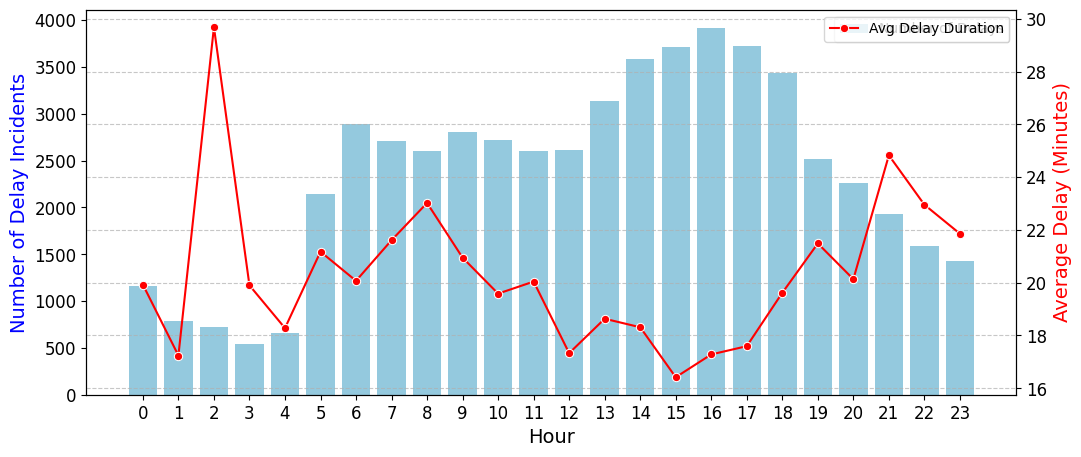

In [9]:
# Need to parse out the hour in the time column, and aggregate by it
# Hour is in string like, '04:38'
dataset_sm['Hour'] = dataset_sm['Time'].apply(lambda x: int(str(x).split(':')[0]) if ':' in str(x) else None)

# Group by hour
stats_by_hour = dataset_sm.groupby('Hour').agg({'Min Delay' : ['count', 'mean']}).reset_index()
stats_by_hour.columns = ['Hour', 'Incident Count', 'Average Delay (Min)']

# graph it
fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(x='Hour', y='Incident Count',
            data=stats_by_hour, ax=ax1, color='skyblue', label='Number of Delays')
ax1.set_ylabel('Number of Delay Incidents', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x='Hour', y='Average Delay (Min)', data=stats_by_hour,
             ax=ax2, color='red', marker='o', label='Avg Delay Duration')
ax2.set_ylabel('Average Delay (Minutes)', color='red')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the graph, it looks like the number of incident reports is highest between 5am and 8pm.  The hours between 1am and 5am sees the least number of incidents.  However, the delays experienced at this time seem to be the highest.  

## Effect of the Days of the week on Delay Events



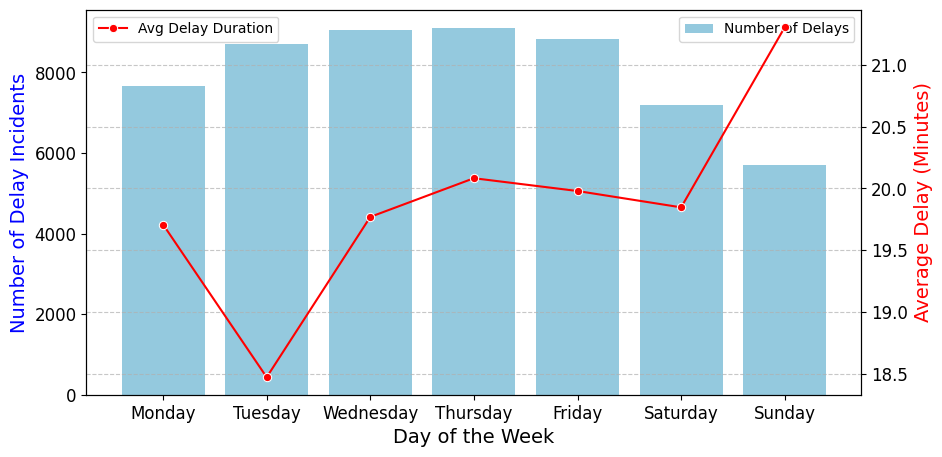

In [10]:
# Going to aggregate by the Day of the week
stats_by_day = dataset_sm.groupby('Day').agg({'Min Delay' : ['count', 'mean']}).reset_index()
stats_by_day.columns = ['Day', 'Incident Count', 'Average Delay (Min)']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reorder the rows by converting 'Day' to a categorical type and sorting
stats_by_day['Day'] = pd.Categorical(stats_by_day['Day'], categories=day_order, ordered=True)
stats_by_day = stats_by_day.sort_values('Day')

# graph it
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='Day', y='Incident Count',
            data=stats_by_day, ax=ax1, color='skyblue', label='Number of Delays')
ax1.set_ylabel('Number of Delay Incidents', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x='Day', y='Average Delay (Min)', data=stats_by_day,
             ax=ax2, color='red', marker='o', label='Avg Delay Duration')
ax2.set_ylabel('Average Delay (Minutes)', color='red')

plt.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_xlabel('Day of the Week')
plt.show()

We can see that while we have fewer incidents on Sundays, the average delay is also the highest on Sundays.

## Which neighborhoods have the most delay?



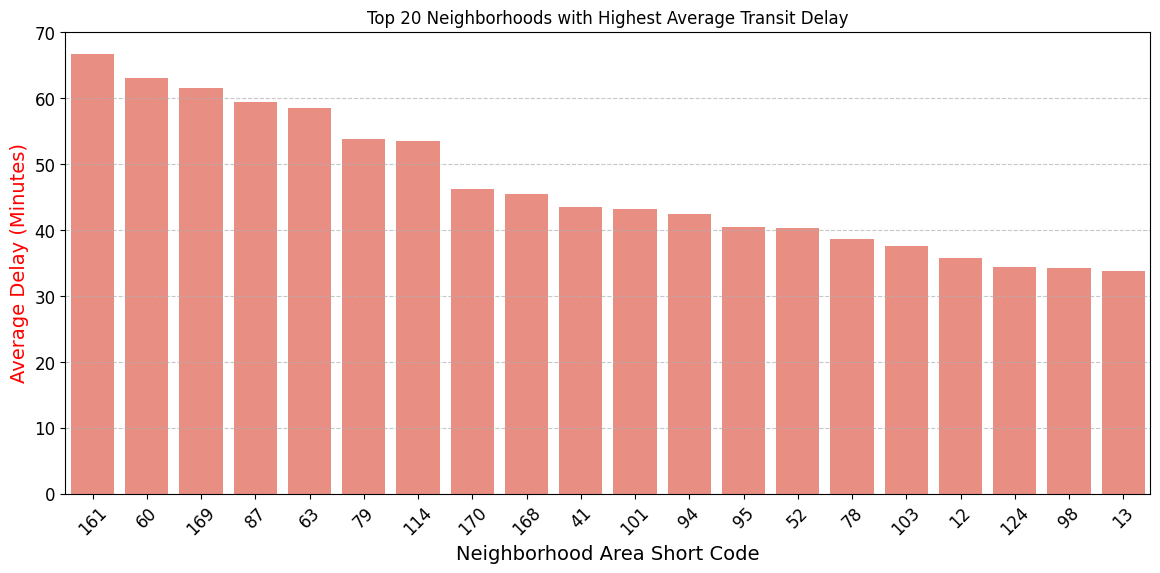

In [11]:
# Aggregate by AREA_SHORT_CODE
stats_by_area = dataset_sm.groupby('AREA_SHORT_CODE').agg({'Min Delay' : ['count', 'mean']}).reset_index()
stats_by_area.columns = ['AREA_SHORT_CODE', 'Incident Count', 'Average Delay (Min)']

# Sort by Average Delay and take the top 20
top_20_areas = stats_by_area.sort_values('Average Delay (Min)', ascending=False).head(20)

# Convert AREA_SHORT_CODE to string to treat it as a categorical label for plotting
top_20_areas['AREA_SHORT_CODE'] = top_20_areas['AREA_SHORT_CODE'].astype(str)

# graph it
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(x='AREA_SHORT_CODE', y='Average Delay (Min)',
            data=top_20_areas, ax=ax1, color='salmon')

ax1.set_ylabel('Average Delay (Minutes)', color='red')
ax1.set_xlabel('Neighborhood Area Short Code')
plt.title('Top 20 Neighborhoods with Highest Average Transit Delay')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import folium

# Get the original coordinates for the top 20 areas
# We ensure AREA_SHORT_CODE is a string to match top_20_areas
top_20_coords = dataset[['AREA_SHORT_CODE', 'latitude', 'longitude', 'AREA_NAME']].drop_duplicates('AREA_SHORT_CODE').copy()
top_20_coords['AREA_SHORT_CODE'] = top_20_coords['AREA_SHORT_CODE'].astype(str)

top_20_map_data = top_20_areas.merge(top_20_coords, on='AREA_SHORT_CODE', how='left')

# Create a map centered around Toronto
m = folium.Map(location=[43.7, -79.4], zoom_start=11)

# Add markers for each of the top 20 neighborhoods
for idx, row in top_20_map_data.iterrows():
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']):
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"Area: {row['AREA_NAME']}<br>Avg Delay: {row['Average Delay (Min)']:.2f} min",
            tooltip=row['AREA_NAME'],
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

display(m)

## Which transit lines experience the most delays?

In [13]:
## Parse out the line number, then aggregate?
# Updated logic to handle cases where 'Line' is just a number (e.g., '600')
def parse_line_number(x):
    s = str(x).strip()
    if s.isnumeric():
        return int(s)
    parts = s.split(' ')
    if parts[0].isnumeric():
        return int(parts[0])
    return None

dataset_sm['Line Number'] = dataset_sm['Line'].apply(parse_line_number).astype('Int64')

line_nums = dataset_sm.groupby('Line Number').agg({'Min Delay' : ['count', 'mean']}).reset_index()
line_nums.columns = ['Line Number', 'Incident Count', 'Average Delay (Min)']

#
print(dataset_sm['Line Number'].isna().sum())
na_lines = dataset_sm[dataset_sm['Line Number'].isna()]['Line'].unique()
print(na_lines)

449
[nan '600/42' 'RAD' 'LINE 1 SHUTTLE' 'FLEET' 'LINE 1 SHUTTLE (600 RA'
 'SHP' 'A421' '600RAD' '89/ / 989 WESTON' 'OTC TRAINING BUS'
 'TRAINING BUS' 'MT DENNIS TEST BUS' 'SHUTTLE BUS' 'RAD BUS' 'OTC' 'BD'
 'REVENUE DEPARTMENT' '39B FINCH EAST' 'YU' 'LINE 1 SHUTTLE BUS' 'RAD 600'
 'A' '600/ 84A SHEPPARD' 'LINE 2 SHUTTLE' '79A SCARLETT ROAD' 'OTC BUS'
 'LINE 1 SHUTTLE (RAD)' '52F LAWRENCE WEST' 'CONSTRUCTION BUS'
 '79B SCARLETT ROAD' 'LINE 2 SHUTTLE BUS' 'LINE 2 SHUTLLE' 'RAD 999'
 'A304' '32A EGLINTON WEST' 'RAD (600)' 'FLEET A398' 'LINE 1'
 '102D MARKHAM ROAD' 'RAD 63' 'FLEET 898' 'LINE 1 - SHUTTLE'
 'LINE 2 SHUTTLE (RAD BU' '600-RAD' '97B YONGE' '939B FINCH EXPRESS'
 'LINE 2 SHUTTLE - 600 R' '94A WELLESLEY' 'FLEET 079' 'NIGHT TRADES'
 '123C SHERWAY' 'HARVEY SHOP REPAIR PER' 'LINE 2' 'REVENUE TRUCK 85' 'SRT'
 'CNE SHUTTLES' 'EMERGENCY SHUTTLE' '34C EGLINTON EAST' '9*7'
 '39C FINCH EAST' 'RAD 72 PAPE' '97C YONGE' '37B ISLINGTON'
 '927D HIGHWAY 27 EXPRE' '24B VICTORIA PARK' 'SHUTTLE LI

In [14]:
# TODO

# Features of Dataset



Instead of using the 'Time' feature in our model, we are using the 'Hour' because the minutes don't matter as much and can overly complicate things.

In [15]:
# Want to parse out the Month from the Date, and give our training model
# more data
dataset_sm['Month'] = dataset_sm['Date'].apply(lambda x: int(str(x).split('-')[1]))



In [16]:
# drop rows where delay is 0
dataset_sm = dataset_sm[dataset_sm['Min Delay'] > 0]

# Our Target is the Min Delay (we can do the same with Min Gap)
y_target_label = 'Min Delay'

datay = dataset_sm[y_target_label]

# what columns of data do we want to train on?
cols_to_train_with = ['Month',
                      'Hour', #'Time',
                      'Day', #'Station',
                      #'Line Number',
                      'Bound',
                      'Total - Age groups of the population - 25% sample data',
                      'Median after-tax income of household in 2020 ($)',
                      'Owner', 'Renter',
                      'Worked at home',
                      'Worked outside Canada',
                      'Usual place of work',
                      'Commute within CSD',
                      'Commute btn CSD',
                      'Commute Intraprovincial',
                      'Commute Interprovincial',
                      'Car, truck or van',
                      'Car, truck or van - as a driver',
                      'Car, truck or van - as a passenger',
                      'Public transit',
                      'Walked',
                      'Bicycle',
                      'Other method',
                      'Less than 15 minutes',
                      '15 to 29 minutes',
                      '30 to 44 minutes',
                      '45 to 59 minutes',
                      '60 minutes and over']

cols_categorical = ['Day', 'Bound']
cols_numerical = [#'Hour',
                  'Total - Age groups of the population - 25% sample data',
                  'Median after-tax income of household in 2020 ($)',
                  'Owner', 'Renter',
                  'Worked at home',
                  'Worked outside Canada',
                  'Usual place of work',
                  'Commute within CSD',
                  'Commute btn CSD',
                  'Commute Intraprovincial',
                  'Commute Interprovincial',
                  'Car, truck or van',
                  'Car, truck or van - as a driver',
                  'Car, truck or van - as a passenger',
                  'Public transit',
                  'Walked',
                  'Bicycle',
                  'Other method',
                  'Less than 15 minutes',
                  '15 to 29 minutes',
                  '30 to 44 minutes',
                  '45 to 59 minutes',
                  '60 minutes and over']
dataX = dataset_sm[cols_to_train_with]

dataX.shape

(49930, 27)

I would like to split the data into the test set and the training set, but immediately came across reframing the problem.  Apparently there is a very high number that only exists once in the 'Min Delay' column.  The train_test_split function could not stratify the data because this single data point cannot be put in both training and test set.

I have 2 options:  I can either not stratify the data, or I can convert this regression problem into a classification problem, and sort the 'Min Delay' into bins of, say, 10-minute chunks.  For our project, I think it makes more sense to bin the 'Min Delay' into 10-min chunks, because it is probably unreasonable to be able to predict delays to the minute.  It may be helpful already to be able to predict that the 'Min Delay' will be around 40 to 50 minutes, then you can find other forms of transportation, or just give up going in for work and work from home instead.  So I am reframing my original regression problem into a multi-class classification problem.  If I still run into the problem where I still cannot stratify, I think I will just increase the bin sizes, or maybe the last bin will just be a 'greater than X minutes' rather than a strict 10-minute duration.

But even before that, I want to try using KMeans to cluster the data to see what groups of delays I have.  Perhaps 10-min intervals are too fine-grained.  Also, it's possible the time duration of bins should increase as time increases.   

# Clustering of Min Delay Data


Let's see if we can use KMeans clustering to classify our data.  This will tell us if there is anything useful in our dataset.

In [17]:
# Create cyclic features for Month
dataset_sm['Month_sin'] = np.sin(2 * np.pi * dataset_sm['Month'] / 12)
dataset_sm['Month_cos'] = np.cos(2 * np.pi * dataset_sm['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
dataset_sm['Hour_sin'] = np.sin(2 * np.pi * dataset_sm['Hour'] / 24)
dataset_sm['Hour_cos'] = np.cos(2 * np.pi * dataset_sm['Hour'] / 24)

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']

In [18]:
data_to_cluster = dataset_sm[cols_to_train_with + cols_cyclic + [y_target_label]].copy()

# drop the 'Month' and 'Hour' columns
data_to_cluster.drop(columns=['Month', 'Hour'], inplace=True)

data_to_cluster.head()

,Day,Bound,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Owner,Renter,Worked at home,Worked outside Canada,Usual place of work,Commute within CSD,Commute btn CSD,Commute Intraprovincial,Commute Interprovincial,"Car, truck or van","Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Walked,Bicycle,Other method,Less than 15 minutes,15 to 29 minutes,30 to 44 minutes,45 to 59 minutes,60 minutes and over,Month_sin,Month_cos,Hour_sin,Hour_cos,Min Delay
0,Wednesday,N,28345,74000,6050,4220,3120,25,7490,6240,0,1240,10,6300,5485,815,2290,405,35,265,1815,2840,2395,975,1270,0.5,0.866025,0.500000,0.866025,20
3,Wednesday,N,20400,62400,990,6070,2130,50,3630,3070,0,550,10,2880,2590,285,1465,405,40,165,925,1285,1380,715,655,0.5,0.866025,0.500000,0.866025,17
4,Wednesday,W,27155,78000,7295,4915,5305,190,5850,4940,0,895,15,5015,4540,480,1145,335,65,270,1130,2610,1865,600,635,0.5,0.866025,0.707107,0.707107,20
7,Wednesday,N,17700,61600,3990,7065,6140,45,3825,3380,0,420,25,1145,980,165,1150,1655,195,160,1065,1565,950,390,345,0.5,0.866025,0.707107,0.707107,5
9,Wednesday,W,27540,76500,7135,1950,2885,80,6570,4670,0,1895,10,6045,5120,920,1465,190,55,140,1315,2515,2095,795,1170,0.5,0.866025,0.866025,0.500000,16


In [19]:
data_to_cluster.shape

(49930, 30)

In [20]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pipeline_categorical = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown="ignore")),
])

pipeline_numerical = Pipeline([
  #('scaler', MinMaxScaler(feature_range=(0,1))),
  ('scaler', StandardScaler())
])

# We should include the target label in the numerical pipeline so it doesn't dominate by scale
#cols_to_scale = cols_numerical + ['Month', 'Hour', y_target_label]
cols_to_scale = cols_numerical + [y_target_label]

pipeline_for_clustering = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale),
])

# Fit and transform the data
data_to_cluster_transformed = pipeline_for_clustering.fit_transform(data_to_cluster)

print(f"data_to_cluster_transformed.shape: {data_to_cluster_transformed.shape}")

data_to_cluster_transformed.shape: (49930, 44)


In [21]:
import numpy as np

# Create cyclic features for Month
#data_to_cluster['Month_sin'] = np.sin(2 * np.pi * data_to_cluster['Month'] / 12)
#data_to_cluster['Month_cos'] = np.cos(2 * np.pi * data_to_cluster['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
#data_to_cluster['Hour_sin'] = np.sin(2 * np.pi * data_to_cluster['Hour'] / 24)
#data_to_cluster['Hour_cos'] = np.cos(2 * np.pi * data_to_cluster['Hour'] / 24)

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
#cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
cols_to_scale_updated = cols_numerical + cols_cyclic + [y_target_label]

# Update the pipeline
pipeline_for_clustering_cyclic = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale_updated),
])

# Transform the data
data_to_cluster_transformed = pipeline_for_clustering_cyclic.fit_transform(data_to_cluster)

print(f"New transformed shape: {data_to_cluster_transformed.shape}")
#display(data_to_cluster[['Month', 'Month_sin', 'Month_cos', 'Hour', 'Hour_sin', 'Hour_cos']].head())

New transformed shape: (49930, 48)


In [22]:
#data_to_cluster_transformed[:10]

In [23]:
def getInertia(X,kmeans):
    inertia = 0
    for J in range(len(X)):
        inertia = inertia + np.linalg.norm(X[J] - kmeans.cluster_centers_[kmeans.labels_[J]])**2
    return inertia

In [24]:
from sklearn import metrics
from sklearn.cluster import KMeans
import numpy as np

kmeans_results = np.zeros(11)
result_silhouette = np.zeros(11)

# Loop over k values using the transformed data (one-hot encoded + raw numerical)
for k in range(0, 10):
    kmeans_model = KMeans(n_clusters=k+1, random_state=0, n_init=10).fit(data_to_cluster_transformed)
    kmeans_results[k+1] = kmeans_model.inertia_
    if k > 0:
        result_silhouette[k+1] = metrics.silhouette_score(data_to_cluster_transformed, kmeans_model.labels_, metric='euclidean')
    print(f"k = {k+1}, inertial_value = {kmeans_results[k+1]:.2f}, silhouette = {result_silhouette[k+1]:.4f}")

k = 1, inertial_value = 1430490.68, silhouette = 0.0000
k = 2, inertial_value = 1023214.73, silhouette = 0.2463
k = 3, inertial_value = 876021.58, silhouette = 0.2611
k = 4, inertial_value = 779456.26, silhouette = 0.1731
k = 5, inertial_value = 724060.93, silhouette = 0.1838
k = 6, inertial_value = 701595.99, silhouette = 0.1614
k = 7, inertial_value = 668952.02, silhouette = 0.1663
k = 8, inertial_value = 633188.67, silhouette = 0.1773
k = 9, inertial_value = 598935.40, silhouette = 0.1896
k = 10, inertial_value = 586805.70, silhouette = 0.1679


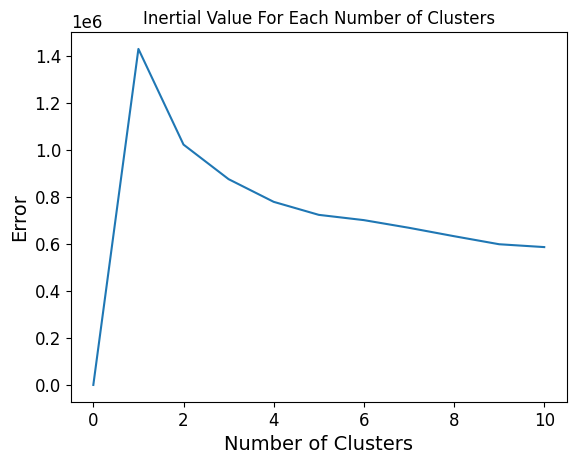

In [25]:
plt.plot(kmeans_results)
plt.title('Inertial Value For Each Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Error')
plt.show()

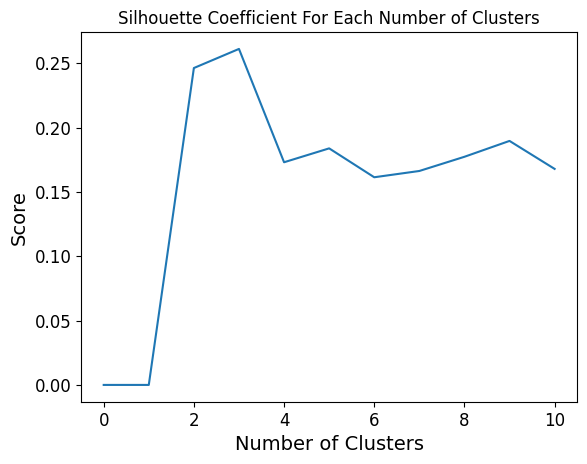

In [26]:
plt.plot(result_silhouette)
plt.title('Silhouette Coefficient For Each Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.show()

From the above graphs, we can see that the data can be partititions quite successfully into 2 to 3 clusters.  For 2 clusters, the silhouette coefficient is 0.25, whereas it is 0.26 for 3 clusters.  If we attempt to increase the number of clusters beyond that, the silhouette drops to hover around 0.17.  

In [27]:
kmeans2 = KMeans(n_clusters=2, random_state=0).fit(data_to_cluster_transformed)

cluster_labels = kmeans2.labels_
print(cluster_labels)
cluster_labels.shape

[0 1 0 ... 1 0 0]


(49930,)

# Peforming PCA on Dataset

We want to know whether all the data we have gathered is actually useful or not.  Thus we perform PCA to see the number of dimensions we require to preserve 95% of the dataset variance.

In [28]:
from sklearn.decomposition import PCA

pca_all = PCA()
pca_all.fit(data_to_cluster_transformed)

cumsum = np.cumsum(pca_all.explained_variance_ratio_)

num_components = np.argmax(cumsum >=0.95) + 1

print('The number of dimensions required to preserve 95% of dataset variance is {}.'.format(num_components))

The number of dimensions required to preserve 95% of dataset variance is 19.


We found that we need at least 19 dimensions.  This is good news since this means that we actually do need most of features we have in the dataset.  Now we will see if we can map the dimensions back to the features in our dataset, to see if we can determine what the top 5 most important features are.

In [29]:
pca_try = PCA(n_components=0.95)
#X_train_reduced = pca_try.fit_transform(X_train)
X_train_reduced = pca_try.fit_transform(data_to_cluster_transformed)

In [30]:
pca_try.explained_variance_ratio_


array([0.41966373, 0.15532978, 0.06488937, 0.03864818, 0.03743557,
       0.03514291, 0.0323499 , 0.03115176, 0.02963363, 0.02600605,
       0.01618651, 0.01475188, 0.01134321, 0.00870617, 0.00796764,
       0.00724566, 0.00674747, 0.00572792, 0.00568133])

In [31]:
import pandas as pd
import numpy as np

# Correctly extract feature names from the cyclic pipeline
# This ensures the names match the 48 features produced by the transformer
cat_features = pipeline_for_clustering_cyclic.named_transformers_['categorical'].get_feature_names_out(cols_categorical).tolist()
num_features = cols_to_scale_updated
feature_names = cat_features + num_features

# Create a DataFrame with the PCA components
pc_indices = [f'PC{i+1}' for i in range(pca_try.n_components_)]
components_df = pd.DataFrame(
    pca_try.components_,
    columns=feature_names,
    index=pc_indices
)

# Get the top 5 features based on the first Principal Component (PC1)
top_5_features = components_df.iloc[0].abs().sort_values(ascending=False).head(5)

print("--- Top 5 Most Important Features from PCA ---")
display(top_5_features)

--- Top 5 Most Important Features from PCA ---


,PC1
Usual place of work,0.287064
30 to 44 minutes,0.277270
15 to 29 minutes,0.277083
Total - Age groups of the population - 25% sample data,0.276488
Commute within CSD,0.272509


# Exploration using tSNE to figure out what our clusters should be


We want to know if there are patterns to these delays, and whether tSNE can help us determine this graphically.

In [32]:
# create a new column called 'Min Delay Temporary', that keys off 'Min Delay'
# is 0 if 'Min Delay' is 0
# is 1 if 'Min Delay' is between 1-10
# is 2 if 'Min Delay' is between 11-20
# is 3 if 'Min Delay' is between 21-30 etc
dataset_sm['Min Delay Temporary'] = pd.cut(dataset_sm['Min Delay'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')],
                                        right=True, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])



In [33]:
data_for_tsne = dataset_sm[cols_categorical + cols_numerical + cols_cyclic]

In [34]:
# import TSNE from sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold     import TSNE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Correct column name for the binned delay. 'Min Delay Temp' should be 'Min Delay Temporary'.
cols_to_scale_tsne = cols_numerical + cols_cyclic

# Redefine pipeline_numerical to include the imputer. The imputer should be applied to numerical features.
pipeline_numerical_with_imputer = Pipeline([
  ('imputer', SimpleImputer(strategy='median')), # Impute numerical columns before scaling
  ('scaler', StandardScaler())
])

# Create a ColumnTransformer for preprocessing all features
preprocessor_for_tsne = ColumnTransformer(transformers=[
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical_with_imputer, cols_to_scale_tsne),
])

# Now construct the final pipeline including the preprocessor and TSNE
tsne_pipeline = Pipeline([
  ('preprocessor', preprocessor_for_tsne),
  ('tsne',    TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)),
])
import time
tsne_start = time.time()
# Transform the data
tsne_result = tsne_pipeline.fit_transform(data_for_tsne)
tsne_end = time.time()
print(f"t-SNE took {tsne_end - tsne_start:.4f} seconds to run")


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 49930 samples in 0.002s...
[t-SNE] Computed neighbors for 49930 samples in 24.608s...
[t-SNE] Computed conditional probabilities for sample 1000 / 49930
[t-SNE] Computed conditional probabilities for sample 2000 / 49930
[t-SNE] Computed conditional probabilities for sample 3000 / 49930
[t-SNE] Computed conditional probabilities for sample 4000 / 49930
[t-SNE] Computed conditional probabilities for sample 5000 / 49930
[t-SNE] Computed conditional probabilities for sample 6000 / 49930
[t-SNE] Computed conditional probabilities for sample 7000 / 49930
[t-SNE] Computed conditional probabilities for sample 8000 / 49930
[t-SNE] Computed conditional probabilities for sample 9000 / 49930
[t-SNE] Computed conditional probabilities for sample 10000 / 49930
[t-SNE] Computed conditional probabilities for sample 11000 / 49930
[t-SNE] Computed conditional probabilities for sample 12000 / 49930
[t-SNE] Computed conditional probabilities for s

/tmp/ipykernel_1323/1353633186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_tsne['tsne-2d-one'] = tsne_result[:, 0]
/tmp/ipykernel_1323/1353633186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_tsne['tsne-2d-two'] = tsne_result[:, 1]
/tmp/ipykernel_1323/1353633186.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

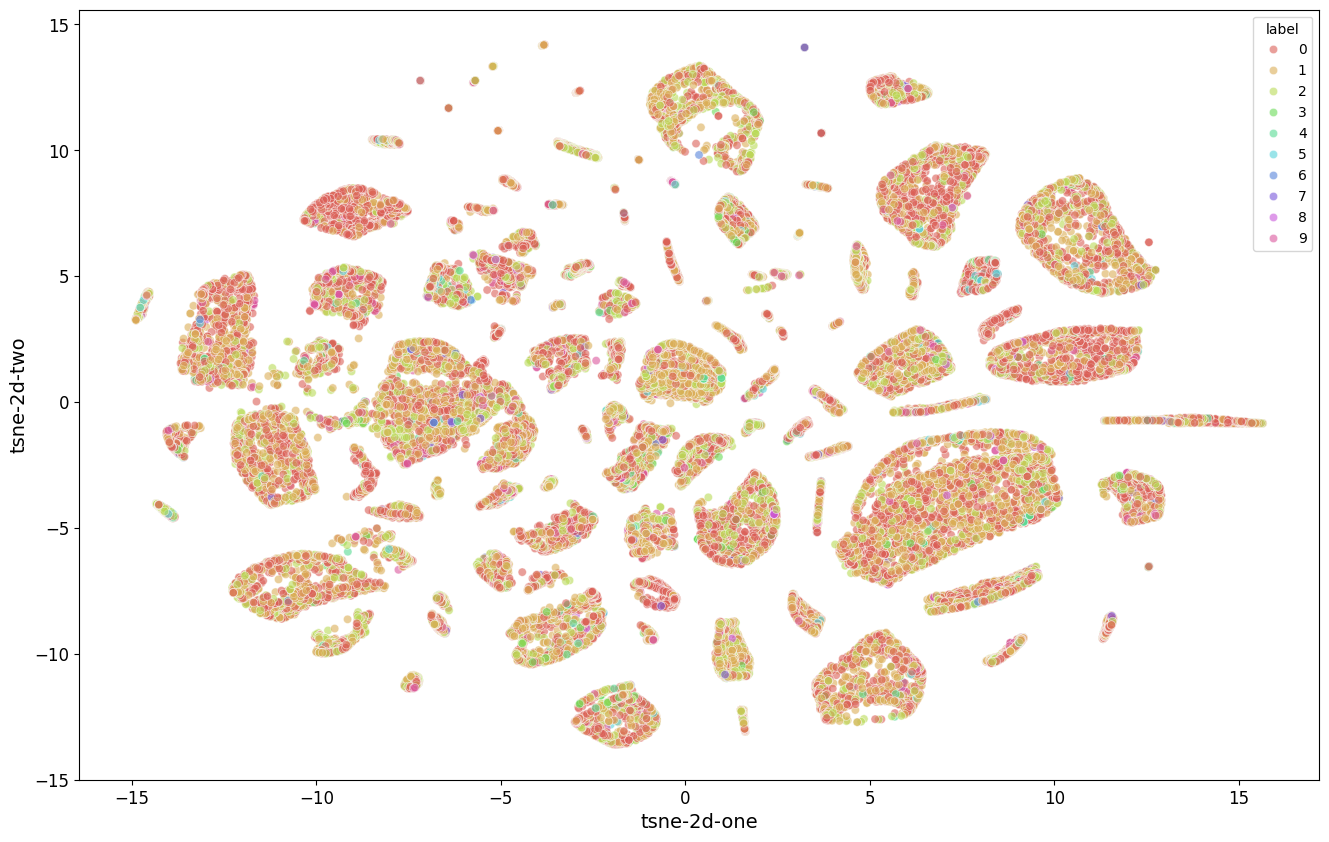

In [35]:
data_for_tsne['tsne-2d-one'] = tsne_result[:, 0]
data_for_tsne['tsne-2d-two'] = tsne_result[:, 1]

# Add the 'label' column for plotting
# Ensure the indices match. X_df_subset is loc[:N] so y_train.loc[:N] should match.
data_for_tsne['label'] = dataset_sm['Min Delay Temporary']

plt.figure(figsize=(16,10))
sns.scatterplot(x='tsne-2d-one', y='tsne-2d-two', hue='label',
               palette=sns.color_palette('hls', 10),
               data=data_for_tsne,
               alpha=0.6)
plt.show()

From the t-SNE plot, we can see clear separation of clusters when I grouped the delays into 10-minute intervals.  However, each group has a smattering of different delays. There appear to be groups, but there is no clear clustering of higher delay points in clear groups.  To try to get more of an understanding, I computed the silhoeutte score for my t-SNE plot.

In [36]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score for the binned labels in the t-SNE space
# This measures how well the delay bins are separated in the 2D plot
score = silhouette_score(tsne_result, dataset_sm['Min Delay Temporary'])

print(f't-SNE Label Separation Score (Silhouette): {score:.4f}')

# Let's also check the distribution of labels to see if one class dominates the clusters
display(data_for_tsne.groupby('label').agg({'tsne-2d-one': ['mean', 'std'], 'tsne-2d-two': ['mean', 'std']}))

t-SNE Label Separation Score (Silhouette): -0.0460


/tmp/ipykernel_1323/2279770148.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(data_for_tsne.groupby('label').agg({'tsne-2d-one': ['mean', 'std'], 'tsne-2d-two': ['mean', 'std']}))


tsne-2d-one            \
             mean       std   
label                         
0        0.044703  7.199049   
1        0.345915  6.898962   
2       -0.546290  6.813657   
3        0.434445  6.390355   
4        0.021222  6.906596   
5       -0.238106  7.336266   
6       -0.389077  6.486306   
7        0.561668  6.482559   
8        0.267970  6.301363   
9       -0.260667  6.634436   

      tsne-2d-two            
             mean       std  
label                        
0        0.207704  6.469082  
1       -0.342370  6.395136  
2        0.568324  6.844390  
3        0.004294  6.561477  
4        0.374757  6.069295  
5        0.926827  6.435881  
6        0.483825  6.476441  
7        0.295265  6.610084  
8        0.967722  6.825880  
9        0.940296  6.790506

Unfortunately, my silhouette score was -0.046.  Having a score >0.5 is supposed to show that we have good distinct clusters and maps well to specific delay durations.  But unfortunately I have a very low score, which indicates that the points are all mixed together.  This means that the current features I have (such as neighborhood stats, and time) are not enough to easily distinguish between a small 10-min delay vs a large, 50-min delay when I try to map this to a 2D view.  The standard of deviation was also very high, which indicates that the points for any given delay duration is scattered all over the map, rather than forming tight, predictable clusters.

From the exploration of the dataset, we likely cannot predict delays in 10-minute intervals.  These intervals will be too fine-grained for us to succeed in building a model.  Thus, we would like to reframe the problem to be a simpler binary classification problem. Let us see if we can succeed in dividing the delays into 2 bins, either something that resolves very fast, or not.

# Delay Prediction

We have decided to reframe our delay prediction into first a binary classification problem. We can predict delays will be either less than a certain threshold, or greater than a certain threshold.  To determine what this threshold should be, we will train and test using our dataset, and record the key values.  

To do this, I first bin the delay according to the threshold, and train a DecisionTreeClassifier (see code below) for the prediction. I experimented ith a few different bin thresholds to gather the data below.

| Bin Threshold | Training Accuracy | Testing Accuracy | Precision Score | Recall Score | F1 Score |
| :--- | :---: | :--- | :--- | :---: | :--- |
| 10 mins | 60.755 % | 61.31 % | 0.607 | 0.934 | 0.736 |
| 15 mins | 63.446 % | 63.15 % | 0.543 | 0.323 | 0.405 |
| 18 mins | 69.082 % | 69.27 % | 0.649 | 0.079 | 0.141 |
| 20 mins | 78.117 % | 78.62 % | 0.598 | 0.0807 | 0.142 |
| 30 mins | 93.135 % | 93.14 % | 0.667 | 0.002915 | 0.0058 |

The problem is that we have much fewer large delays, so my dataset is not balanced.  Although we seem great in predicting delays less than 30 mins, this is because we have very few large delays.  From this data, it looks like we should probably set our bin threshold to 10 minutes.  It yields the best f1 score, and gets us 61.31 % test accuracy. It is still useful to be able to predict that the bus is either going to be relatively on time (within 10 mins of delay), or much more significantly delayed (greater than 10 mins).

In [37]:
# create a new column called 'Min Delay Binned', that keys off 'Min Delay'
# is 0 if 'Min Delay' is 0
# is 1 if 'Min Delay' is between 1-10
# is 2 if 'Min Delay' is between 11-20
# is 3 if 'Min Delay' is between 21-30 etc
dataset_sm['Min Delay Binned'] = pd.cut(dataset_sm['Min Delay'], bins=[0, 10, float('inf')],#, 20, 30, 40, 50, 60, 70, 80, float('inf')],
                                        right=True, labels=[0, 1]) #, 3, 4, 5, 6, 7, 8, 9])

# changing the y_target_lable
y_target_label = 'Min Delay Binned'

datay = dataset_sm[y_target_label]

dataset_sm[['Min Delay','Min Delay Binned']].head(10)

,Min Delay,Min Delay Binned
0,20,1
3,17,1
4,20,1
7,5,0
9,16,1
10,20,1
12,30,1
15,15,1
18,10,0
19,17,1


In [38]:
# Create cyclic features for Month
dataX['Month_sin'] = np.sin(2 * np.pi * dataX['Month'] / 12)
dataX['Month_cos'] = np.cos(2 * np.pi * dataX['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
dataX['Hour_sin'] = np.sin(2 * np.pi * dataX['Hour'] / 24)
dataX['Hour_cos'] = np.cos(2 * np.pi * dataX['Hour'] / 24)


/tmp/ipykernel_1323/469173915.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataX['Month_sin'] = np.sin(2 * np.pi * dataX['Month'] / 12)
/tmp/ipykernel_1323/469173915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataX['Month_cos'] = np.cos(2 * np.pi * dataX['Month'] / 12)
/tmp/ipykernel_1323/469173915.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [39]:
dataX.shape

(49930, 31)

In [40]:
# need to split the dataset into training set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataX, datay, test_size=0.2, random_state=123, stratify=datay)
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")


X_train.shape: (39944, 31)
X_test.shape: (9986, 31)
y_train.shape: (39944,)
y_test.shape: (9986,)


In [41]:
display(X_train)
display(y_train)

,Month,Hour,Day,Bound,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Owner,Renter,Worked at home,Worked outside Canada,Usual place of work,Commute within CSD,Commute btn CSD,Commute Intraprovincial,Commute Interprovincial,"Car, truck or van","Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Walked,Bicycle,Other method,Less than 15 minutes,15 to 29 minutes,30 to 44 minutes,45 to 59 minutes,60 minutes and over,Month_sin,Month_cos,Hour_sin,Hour_cos
28707,6,19,Monday,NaN,24305,71500,5260,3460,2430,25,6765,5510,0,1250,10,4970,4335,640,2465,340,30,160,1310,2230,2070,1005,1350,1.224647e-16,-1.000000e+00,-0.965926,0.258819
55680,11,9,Saturday,N,15485,73500,3375,4515,4890,20,3595,3165,0,425,0,1750,1490,265,1250,635,510,210,740,1485,1320,425,390,-5.000000e-01,8.660254e-01,0.707107,-0.707107
15237,4,5,Monday,S,13965,86000,2385,2665,2180,25,3160,2565,0,585,15,2820,2490,330,720,170,20,140,650,1290,1100,395,435,8.660254e-01,-5.000000e-01,0.965926,0.258819
9446,2,19,Friday,N,22665,85000,6245,4210,6495,50,4620,3770,0,830,25,3080,2825,255,1420,480,275,245,920,1835,1695,550,495,8.660254e-01,5.000000e-01,-0.965926,0.258819
7925,2,14,Friday,N,24305,71500,5260,3460,2430,25,6765,5510,0,1250,10,4970,4335,640,2465,340,30,160,1310,2230,2070,1005,1350,8.660254e-01,5.000000e-01,-0.500000,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13397,3,10,Wednesday,NaN,15485,84000,3915,1695,2890,115,2950,2205,0,730,10,2445,2190,255,825,120,20,80,525,1155,1090,420,295,1.000000e+00,6.123234e-17,0.500000,-0.866025
19245,5,10,Friday,S,11290,93000,2855,2045,3145,25,2205,2010,0,175,20,1155,1020,130,615,465,270,90,460,1010,725,215,190,5.000000e-01,-8.660254e-01,0.500000,-0.866025
61096,12,22,Sunday,W,22735,68500,4010,9170,7330,95,5195,4560,0,610,30,2410,2155,255,2655,665,110,215,930,1905,2005,665,550,-2.449294e-16,1.000000e+00,-0.500000,0.866025
21881,5,16,Sunday,W,10120,115000,2990,845,2825,10,1995,1630,0,360,0,1305,1230,75,535,225,90,160,495,625,750,275,170,5.000000e-01,-8.660254e-01,-0.866025,-0.500000


,Min Delay Binned
28707,0
55680,0
15237,1
9446,1
7925,1
...,...
13397,0
19245,1
61096,1
21881,0


We appy one-hot encoding to categorical features such as Day of the week, and direction the travel was.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
cols_to_scale_updated = cols_numerical + cols_cyclic

pipeline_categorical = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown="ignore")),
])

pipeline_numerical = Pipeline([
  #('scaler', MinMaxScaler(feature_range=(0,1))),
  ('scaler', StandardScaler()),
])

# Update the pipeline
pipeline_full = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale_updated),
])


In [43]:
pipeline_full

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Day', 'Bound']),
                                ('numerical',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Total - Age groups of the population - 25% '
                                  'sample data',
                                  'Median after-tax income of household in '
                                  '2020 ($)',
                                  'Owner', 'Renter', 'Worked at home',
                                  'Worked outside Canada',
                                  'Usual pla...work', 'Commute within CSD',
                                  'Commute btn CSD', 'Commute Intraprovincial',
                                  'Commute Interprovincial',
                                  'Car, truck or van',
                                  'Car, truck or van - as a driver',
                                  'Car, truck or van - as a passenger',
                                  'Public transit', 'Walked', 'Bicycle',
                                  'Other method', 'Less than 15 minutes',
                                  '15 to 29 minutes', '30 to 44 minutes',
                                  '45 to 59 minutes', '60 minutes and over',
                                  'Month_sin', 'Month_cos', 'Hour_sin',
                                  'Hour_cos'])])

In [44]:
pipeline_full.fit(X_train)
X_train_transformed = pipeline_full.transform(X_train)
X_test_transformed = pipeline_full.transform(X_test)
print(f"X_train_transformed.shape: {X_train_transformed.shape}")
print(f"X_test_transformed.shape: {X_test_transformed.shape}")

X_train_transformed.shape: (39944, 46)
X_test_transformed.shape: (9986, 46)


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

tree_clf = DecisionTreeClassifier(max_depth=5, criterion='entropy')
start_time_tree_clf = time.time()

rf_cv_score = cross_val_score(tree_clf, X_train_transformed, y_train, cv=5)

end_time_tree_clf = time.time()

print('Decision Tree mean accuracy: ', round(rf_cv_score.mean()*100, 3), '% std: ', round(rf_cv_score.var()*100, 3),'%')
time_tree = end_time_tree_clf - start_time_tree_clf
print(f"cross_val_score of DecisionTreeClassifier took {time_tree:.4f} seconds to run")

Decision Tree mean accuracy:  60.755 % std:  0.002 %
cross_val_score of DecisionTreeClassifier took 0.8762 seconds to run


Decision Tree accuracy_score: 0.6130582815942319
Decision Tree precision_score: 0.6072837974968993
Decision Tree recall_score: 0.9339344546558003
Decision Tree f1_score: 0.7359934408308281
Decision Tree roc_auc_score: 0.6149131397252382
test accuracy for Decision Tree Classifier: 61.31 %


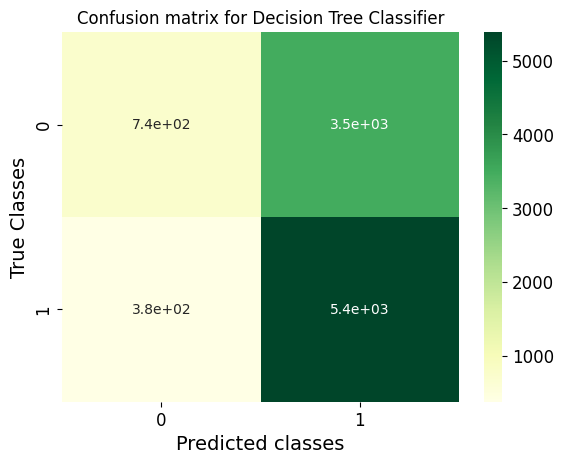

In [46]:
# now evaluate the model using the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# do the fit
tree_clf.fit(X_train_transformed, y_train)

# do the predict using test set
tree_y_pred = tree_clf.predict(X_test_transformed)
tree_y_pred_proba = tree_clf.predict_proba(X_test_transformed)

test_accuracy_tree = accuracy_score(y_test, tree_y_pred)
print(f"Decision Tree accuracy_score: {accuracy_score(y_test, tree_y_pred)}")
print(f"Decision Tree precision_score: {precision_score(y_test, tree_y_pred)}")
print(f"Decision Tree recall_score: {recall_score(y_test, tree_y_pred)}")
print(f"Decision Tree f1_score: {f1_score(y_test, tree_y_pred)}")
print(f"Decision Tree roc_auc_score: {roc_auc_score(y_test, tree_y_pred_proba[:,1])}")

print('test accuracy for Decision Tree Classifier:'\
      , round(accuracy_score(y_test, tree_y_pred)*100, 2), '%')
plt.title('Confusion matrix for Decision Tree Classifier')
sns.heatmap(confusion_matrix(y_test, tree_y_pred), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

# Hyperparameter Search

Now that we have decided on having a bin threshold of 10 minutes, we perform some hyperparameter search to see if we can improve our accuracy.  We will use RandomizedSearchCV to help us find better parameters.


In [47]:
from sklearn.model_selection import RandomizedSearchCV

# Expanded parameter distribution
distri_v2 = {
    'max_depth': range(5, 25),
    'min_samples_leaf': range(1, 15),
    'min_samples_split': range(2, 20),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    # Cost Complexity Pruning - values usually between 0 and 0.05
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
    # Handling class imbalance
    'class_weight': [None, 'balanced'],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

tree_model_v2 = DecisionTreeClassifier(random_state=123)

random_search_v2 = RandomizedSearchCV(
    estimator=tree_model_v2,
    param_distributions=distri_v2,
    scoring='roc_auc',
    cv=5,
    n_iter=200,
    random_state=123,
    n_jobs=-1
)

random_search_v2.fit(X_train_transformed, y_train)

print("Best parameters found:", random_search_v2.best_params_)
print("\n", random_search_v2.best_estimator_)
print("Best F1 Score:", random_search_v2.best_score_)

Best parameters found: {'min_samples_split': 19, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_features': None, 'max_depth': 22, 'criterion': 'gini', 'class_weight': None, 'ccp_alpha': 0.0}

 DecisionTreeClassifier(max_depth=22, min_impurity_decrease=0.0001,
                       min_samples_split=19, random_state=123)
Best F1 Score: 0.6687919159448219


In [48]:
print("\n", random_search_v2.best_estimator_)


 DecisionTreeClassifier(max_depth=22, min_impurity_decrease=0.0001,
                       min_samples_split=19, random_state=123)


In [49]:
# let's use the parameters to train our model and see if our results improve

randomCV_final = DecisionTreeClassifier(max_depth=22, min_impurity_decrease=0.0001,
                       min_samples_split=19, random_state=123)

#randomCV_final = DecisionTreeClassifier(criterion='entropy', max_depth=15, max_features='sqrt',
#                       min_samples_leaf=7, min_samples_split=3,
#                       random_state=123)

rand_start = time.time()
randomCV_final_cv_score = cross_val_score(randomCV_final, X_train_transformed, y_train, cv=5)
rand_end = time.time()
rand_time = rand_end - rand_start
print('Final Decision Tree mean accuracy: ', round(randomCV_final_cv_score.mean()*100, 3), '% std: ', round(randomCV_final_cv_score.var()*100, 3),'%')
print(f"cross_val_score of DecisionTreeClassifier took {rand_time:.4f} seconds to run")


Final Decision Tree mean accuracy:  63.629 % std:  0.003 %
cross_val_score of DecisionTreeClassifier took 1.5078 seconds to run


Final Decision Tree accuracy_score: 0.6419
Final Decision Tree precision_score: 0.6544
Final Decision Tree recall_score: 0.8051
Final Decision Tree f1_score: 0.7220
Final Decision Tree roc_auc_score: 0.6871


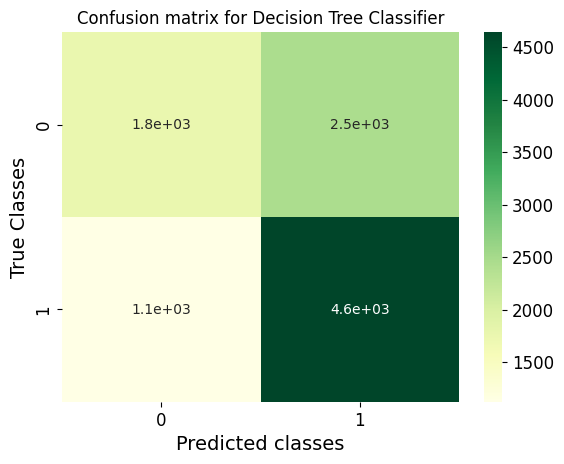

In [52]:
# try out the test set
# do the fit
randomCV_final.fit(X_train_transformed, y_train)

# do the predict using test set
randomCV_final_y_pred = randomCV_final.predict(X_test_transformed)
randomCV_final_y_pred_proba = randomCV_final.predict_proba(X_test_transformed)

print(f"Final Decision Tree accuracy_score: {accuracy_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree precision_score: {precision_score(y_test, randomCV_final_y_pred):.4f}")

print(f"Final Decision Tree recall_score: {recall_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree f1_score: {f1_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree roc_auc_score: {roc_auc_score(y_test, randomCV_final_y_pred_proba[:,1]):.4f}")

plt.title('Confusion matrix for Decision Tree Classifier')
sns.heatmap(confusion_matrix(y_test, randomCV_final_y_pred), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

After some hyperparameter search, the best training accuracy achieved is 63.63%.  The DecisionTreeClassifier has the following hyperparameters:
 * max_depth=22
 * min_impurity_decrease=0.0001,
 * min_samples_split=19
 * random_state=123

The test accuracy is slightly better at 64.2%. The F1 score is not too bad at 0.722.




# Learning Curve

Now I wil plot the learning curve to see if my model is overfitting or underfitting.

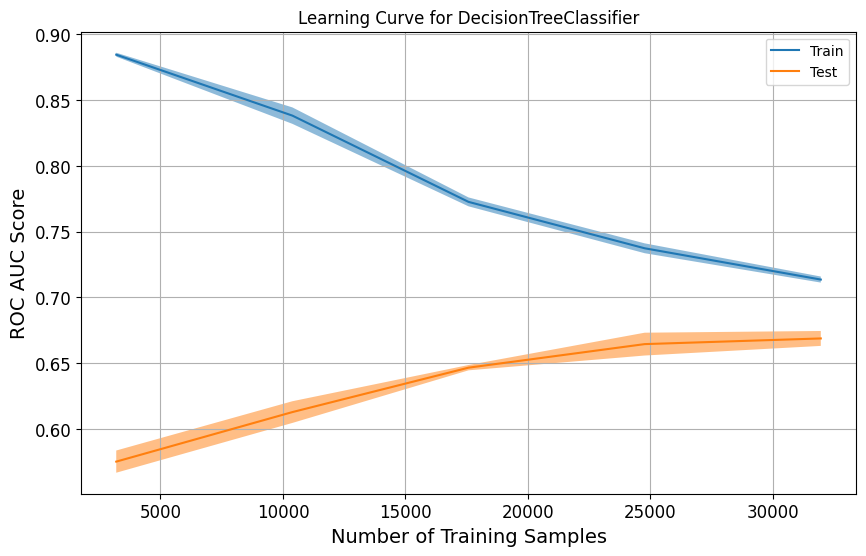

In [51]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
LearningCurveDisplay.from_estimator(
    randomCV_final,
    X_train_transformed,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    ax=ax
)
ax.set_title("Learning Curve for DecisionTreeClassifier")
ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("ROC AUC Score")
ax.grid(True)
plt.show()

The Learning Curve of the DecisionTreeClassifier actually looks really good!  I am happy wth our model, although we can always explore additional models to see if we can improve upon this result.
